In [1]:
import torch
 
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

import pandas as pd
#from ctgan import CTGAN

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

True
NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
df = pd.read_csv("../data/raw/train_clean.csv")

In [3]:
# create metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

df_good = df[df["Credit_Score"] == "Good"]
df_standard = df[df["Credit_Score"] == "Standard"]
df_poor = df[df["Credit_Score"] == "Poor"]


In [4]:
EPOCH_COUNT = 50

# create model
model_good = CTGANSynthesizer(
    metadata,
    epochs=EPOCH_COUNT,
    cuda=True,
    verbose=True
)

model_poor = CTGANSynthesizer(
    metadata,
    epochs=EPOCH_COUNT,
    cuda=True,
    verbose=True
)

# esto es para ver por curiosidad que pasa si creo datos completamente synteticos con la
#ctgan
model_standard = CTGANSynthesizer(
    metadata,
    epochs=EPOCH_COUNT,
    cuda=True,
    verbose=True
)

/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope/tf_env/lib/python3.10/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope/tf_env/lib/python3.10/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope/tf_env/lib/python3.10/site-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


In [5]:
model_good.fit(df_good)
model_poor.fit(df_poor)
model_standard.fit(df_standard)

Gen. (-03.49) | Discrim. (-00.01): 100%|████████████████████████████████████████████████| 50/50 [01:07<00:00,  1.36s/it]
Gen. (-01.72) | Discrim. (-00.51): 100%|████████████████████████████████████████████████| 50/50 [01:54<00:00,  2.29s/it]
Gen. (-01.52) | Discrim. (-00.11): 100%|████████████████████████████████████████████████| 50/50 [03:27<00:00,  4.14s/it]


In [6]:
target_size = len(df_standard)

n_good_needed = target_size - len(df_good)
n_poor_needed = target_size - len(df_poor)

print(n_good_needed, n_poor_needed)

32679 21886


In [7]:
synthetic_good = model_good.sample(n_good_needed)
synthetic_poor = model_poor.sample(n_poor_needed)

In [8]:
df_balanced = pd.concat([
    df,
    synthetic_good
    ,synthetic_poor
])

print(df_balanced["Credit_Score"].value_counts())

Credit_Score
Good        48253
Standard    48253
Poor        48253
Name: count, dtype: int64


# ------------------
## export data in to 2 csvs
# ------------------

### create balanced data set with original data (basically: REAL + SYNTHETIC)


In [9]:
df_balanced = pd.concat([
    df,
    synthetic_good,
    synthetic_poor
])

print("\nBalanced (mixed) distribution:")
print(df_balanced["Credit_Score"].value_counts())




Balanced (mixed) distribution:
Credit_Score
Good        48253
Standard    48253
Poor        48253
Name: count, dtype: int64


In [10]:
df_balanced.to_csv("../data/processed/train_balanced_mixed.csv", index=False)

### Synthetic balanced dataset

In [11]:
TARGET_PER_CLASS = 20000

# Generate synthetic for each class
synthetic_good_sampled = model_good.sample(TARGET_PER_CLASS)
synthetic_poor_sampled = model_poor.sample(TARGET_PER_CLASS)
synthetic_standard_sampled = model_standard.sample(TARGET_PER_CLASS)

# Combine em
df_synthetic_balanced = pd.concat([
    synthetic_good_sampled,
    synthetic_standard_sampled,
    synthetic_poor_sampled
])

print(df_synthetic_balanced["Credit_Score"].value_counts())

# Save
df_synthetic_balanced.to_csv("../data/processed/train_balanced_synthetic.csv", index=False)

Credit_Score
Good        20000
Standard    20000
Poor        20000
Name: count, dtype: int64


# --------------------------------
## verify how it looks
# --------------------------------

In [19]:
from sdv.evaluation.single_table import evaluate_quality

quality_report_synthetic_good = evaluate_quality(
    real_data=df_good,
    synthetic_data=synthetic_good,
    metadata=metadata
)
print("--"*50)
quality_report_synthetic_poor = evaluate_quality(
    real_data=df_poor,
    synthetic_data=synthetic_poor,
    metadata=metadata
)
print("--"*50)
quality_report_synthetic_standard = evaluate_quality(
    real_data=df_standard,
    synthetic_data=synthetic_standard_sampled,
    metadata=metadata
)
print("--"*50)


Generating report ...

(1/2) Evaluating Column Shapes: |█████████████████████████████████████████████████████| 32/32 [00:00<00:00, 201.41it/s]|
Column Shapes Score: 89.74%

(2/2) Evaluating Column Pair Trends: |███████████████████████████████████████████████| 496/496 [00:11<00:00, 43.39it/s]|
Column Pair Trends Score: 74.8%

Overall Score (Average): 82.27%

----------------------------------------------------------------------------------------------------
Generating report ...

(1/2) Evaluating Column Shapes: |█████████████████████████████████████████████████████| 32/32 [-00:10<00:00, -3.16it/s]|
Column Shapes Score: 89.29%

(2/2) Evaluating Column Pair Trends: |██████████████████████████████████████████████| 496/496 [00:02<00:00, 246.06it/s]|
Column Pair Trends Score: 81.65%

Overall Score (Average): 85.47%

----------------------------------------------------------------------------------------------------
Generating report ...

(1/2) Evaluating Column Shapes: |█████████████████████

## further table analysis

In [13]:
import matplotlib.pyplot as plt

columns = [
    "Age","Occupation","Annual_Income","Monthly_Inhand_Salary",
    "Num_Bank_Accounts","Num_Credit_Card","Interest_Rate",
    "Num_of_Loan","Delay_from_due_date","Num_of_Delayed_Payment",
    "Changed_Credit_Limit","Num_Credit_Inquiries","Credit_Mix",
    "Outstanding_Debt","Credit_Utilization_Ratio",
    "Payment_of_Min_Amount","Amount_invested_monthly",
    "Monthly_Balance","Credit_Score","Credit_History_Years",
    "Spending_Level","Payment_Size"
]

def compare_datasets(real, synthetic, columns):
    
    numerical_cols = real[columns].select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = real[columns].select_dtypes(include=['object']).columns

    print("\n==============================")
    print("NUMERICAL COLUMN ANALYSIS")
    print("==============================")

    for col in numerical_cols:
        print(f"\n--- {col} ---")
        
        # Stats
        real_mean = real[col].mean()
        synth_mean = synthetic[col].mean()
        real_std = real[col].std()
        synth_std = synthetic[col].std()

        print(f"Real Mean: {real_mean:.2f} | Synthetic Mean: {synth_mean:.2f}")
        print(f"Real Std:  {real_std:.2f} | Synthetic Std:  {synth_std:.2f}")

        # Plot
        plt.figure()
        plt.hist(real[col].dropna(), bins=50, alpha=0.5, label="Real", density=True)
        plt.hist(synthetic[col].dropna(), bins=50, alpha=0.5, label="Synthetic", density=True)
        plt.legend()
        plt.title(col)
        plt.show()

    print("\n==============================")
    print("CATEGORICAL COLUMN ANALYSIS")
    print("==============================")

    for col in categorical_cols:
        print(f"\n--- {col} ---")

        real_counts = real[col].value_counts(normalize=True)
        synth_counts = synthetic[col].value_counts(normalize=True)

        comparison = pd.DataFrame({
            "Real": real_counts,
            "Synthetic": synth_counts
        }).fillna(0)

        print(comparison)

        # Plot
        comparison.plot(kind='bar')
        plt.title(col)
        plt.show()

## a bunch of tables for df good


NUMERICAL COLUMN ANALYSIS

--- Age ---
Real Mean: 36.38 | Synthetic Mean: 32.36
Real Std:  11.10 | Synthetic Std:  11.83


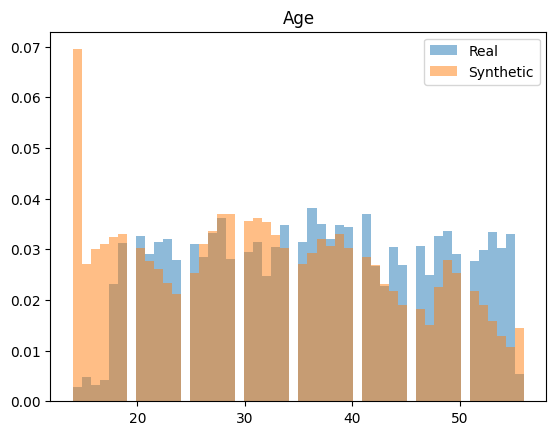


--- Annual_Income ---
Real Mean: 59741.76 | Synthetic Mean: 68558.22
Real Std:  38736.04 | Synthetic Std:  43585.05


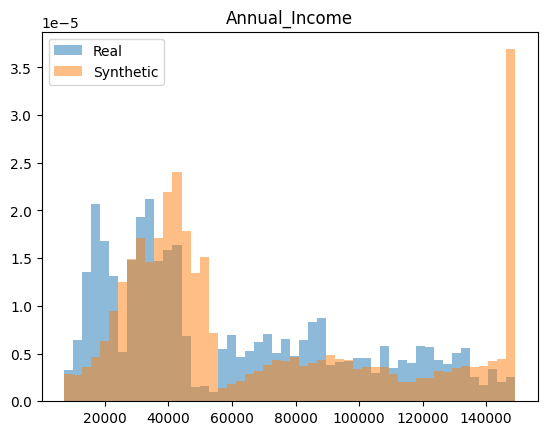


--- Monthly_Inhand_Salary ---
Real Mean: 4949.64 | Synthetic Mean: 4593.28
Real Std:  3217.40 | Synthetic Std:  3017.67


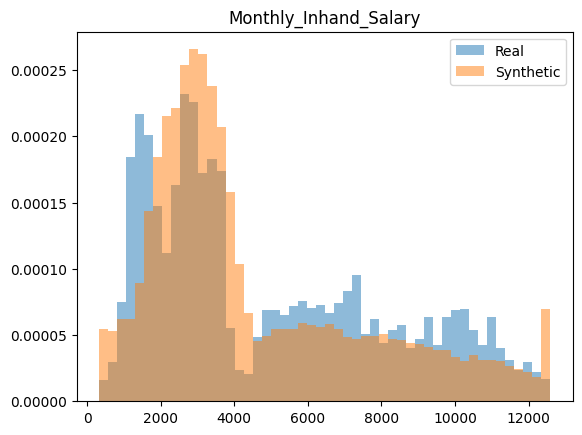


--- Num_Bank_Accounts ---
Real Mean: 3.47 | Synthetic Mean: 3.49
Real Std:  2.23 | Synthetic Std:  2.36


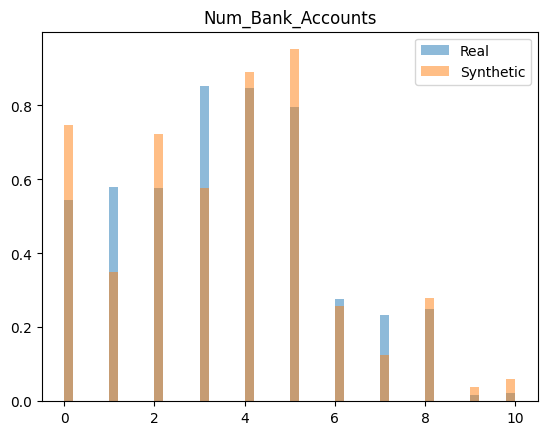


--- Num_Credit_Card ---
Real Mean: 4.15 | Synthetic Mean: 4.22
Real Std:  1.82 | Synthetic Std:  1.85


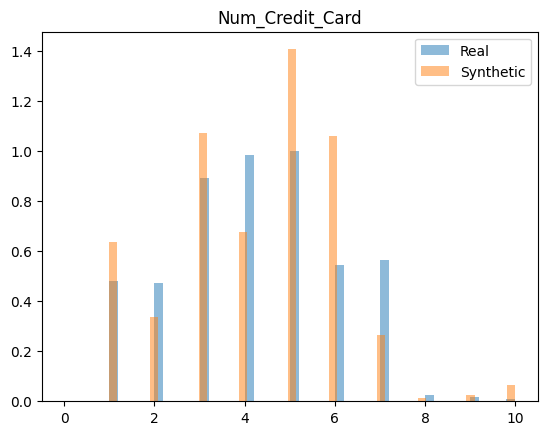


--- Interest_Rate ---
Real Mean: 7.72 | Synthetic Mean: 8.58
Real Std:  4.92 | Synthetic Std:  4.86


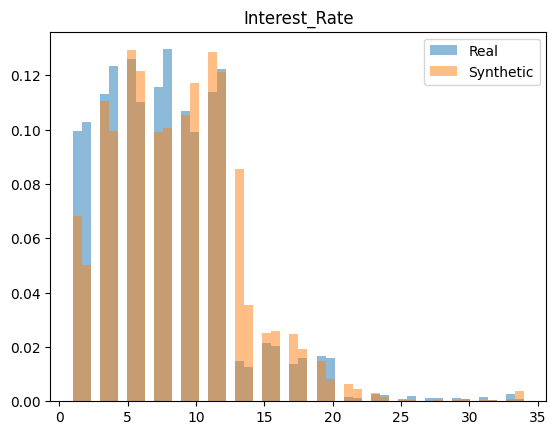


--- Num_of_Loan ---
Real Mean: 2.21 | Synthetic Mean: 2.59
Real Std:  1.66 | Synthetic Std:  1.80


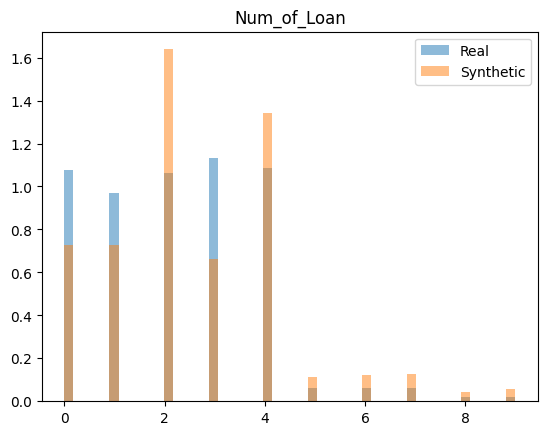


--- Delay_from_due_date ---
Real Mean: 11.12 | Synthetic Mean: 13.94
Real Std:  8.47 | Synthetic Std:  10.88


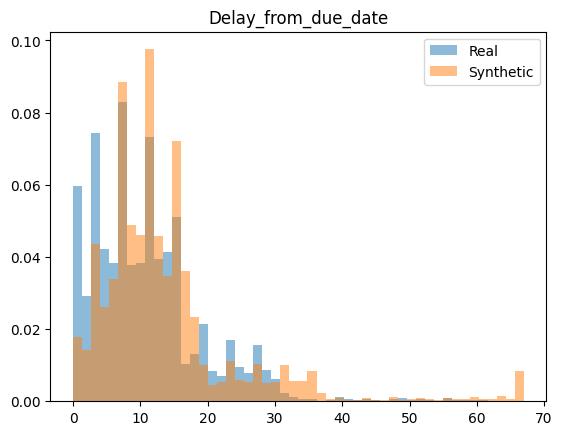


--- Num_of_Delayed_Payment ---
Real Mean: 24.70 | Synthetic Mean: 43.74
Real Std:  212.80 | Synthetic Std:  320.01


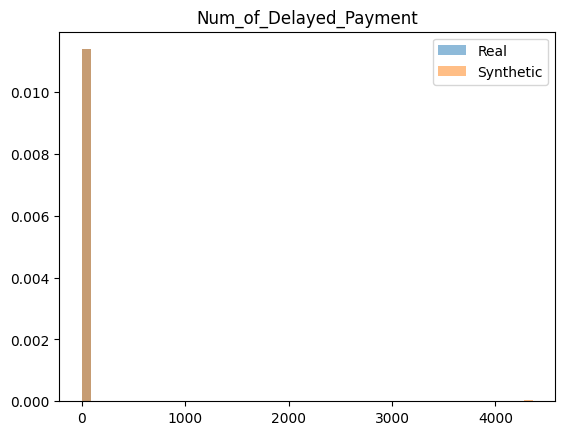


--- Changed_Credit_Limit ---
Real Mean: 7.17 | Synthetic Mean: 7.60
Real Std:  4.56 | Synthetic Std:  5.60


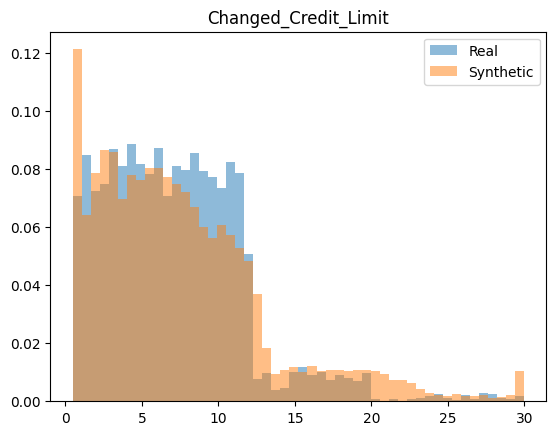


--- Num_Credit_Inquiries ---
Real Mean: 3.18 | Synthetic Mean: 3.25
Real Std:  2.46 | Synthetic Std:  2.90


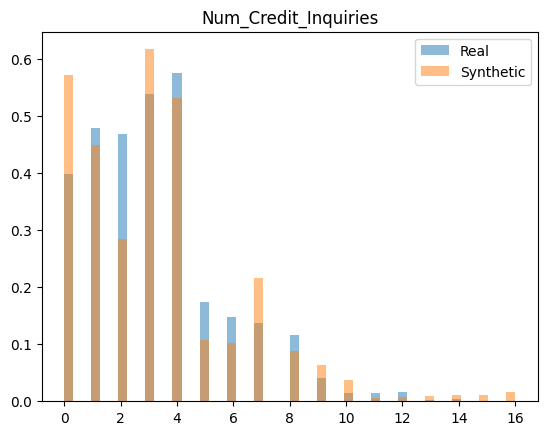


--- Outstanding_Debt ---
Real Mean: 803.55 | Synthetic Mean: 888.95
Real Std:  615.88 | Synthetic Std:  792.93


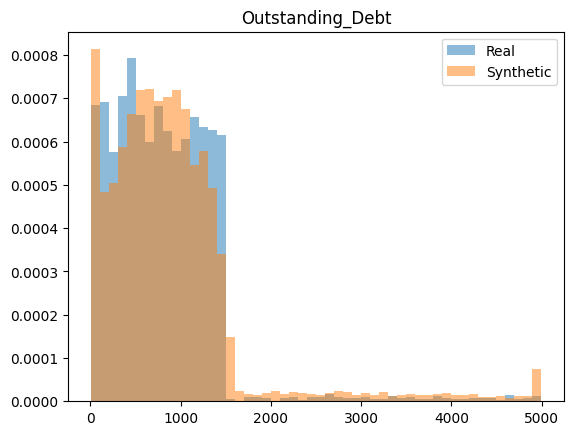


--- Credit_Utilization_Ratio ---
Real Mean: 32.53 | Synthetic Mean: 33.15
Real Std:  5.14 | Synthetic Std:  5.97


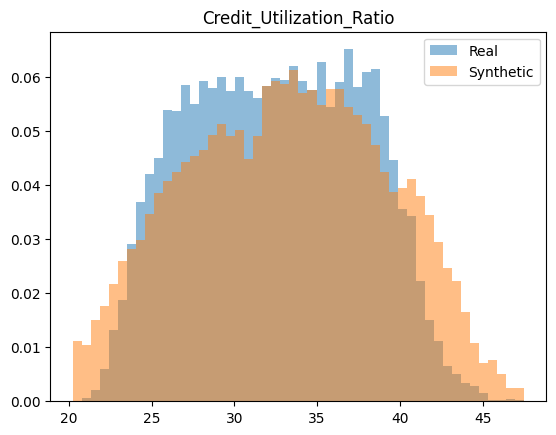


--- Amount_invested_monthly ---
Real Mean: 198.36 | Synthetic Mean: 129.80
Real Std:  134.74 | Synthetic Std:  109.34


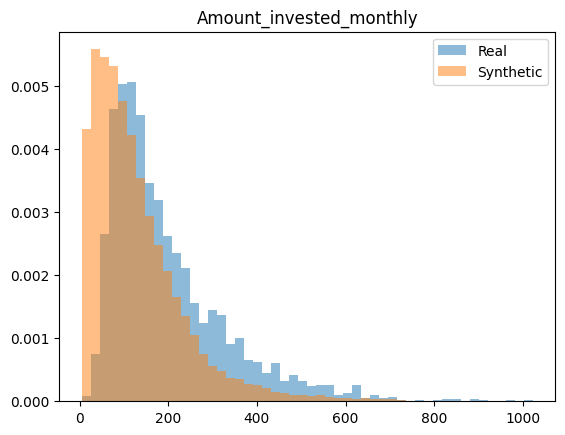


--- Monthly_Balance ---
Real Mean: 456.41 | Synthetic Mean: 491.16
Real Std:  220.21 | Synthetic Std:  258.85


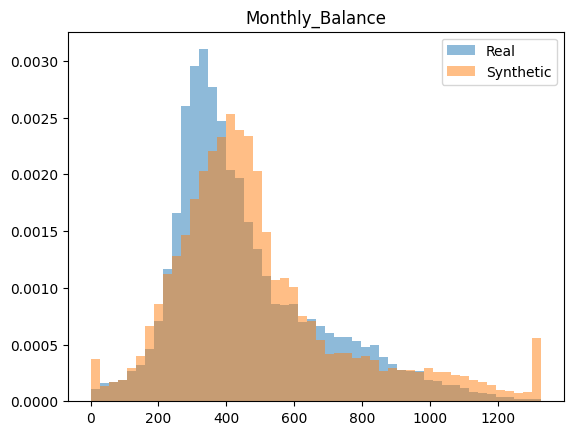


--- Credit_History_Years ---
Real Mean: 23.22 | Synthetic Mean: 22.54
Real Std:  6.15 | Synthetic Std:  7.06


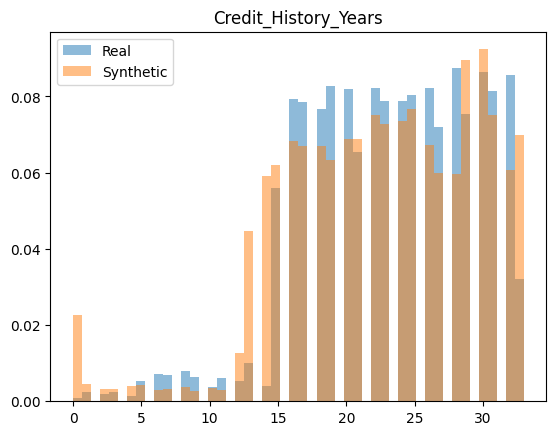


CATEGORICAL COLUMN ANALYSIS

--- Occupation ---
                   Real  Synthetic
Occupation                        
Accountant     0.066328   0.041189
Architect      0.068640   0.104379
Developer      0.066457   0.064323
Doctor         0.066072   0.041586
Engineer       0.070952   0.070596
Entrepreneur   0.064595   0.068331
Journalist     0.070053   0.082622
Lawyer         0.070887   0.077940
Manager        0.069539   0.064996
Mechanic       0.062283   0.057835
Media_Manager  0.071529   0.061507
Musician       0.065558   0.068240
Scientist      0.066007   0.043422
Teacher        0.071144   0.112672
Writer         0.049955   0.040362


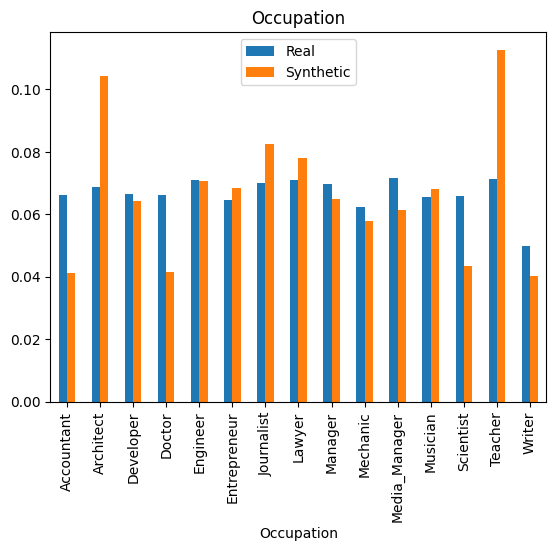


--- Credit_Mix ---
                Real  Synthetic
Credit_Mix                     
Good        0.823552   0.813917
Standard    0.156415   0.138621
Bad         0.020033   0.047462


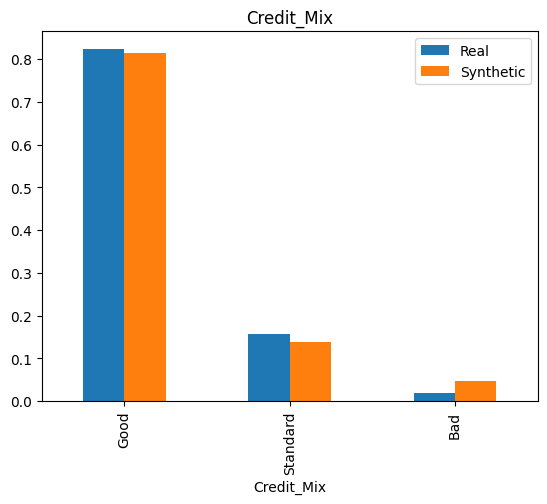


--- Payment_of_Min_Amount ---
                           Real  Synthetic
Payment_of_Min_Amount                     
No                     0.760819   0.650448
NM                     0.126557   0.241531
Yes                    0.112624   0.108020


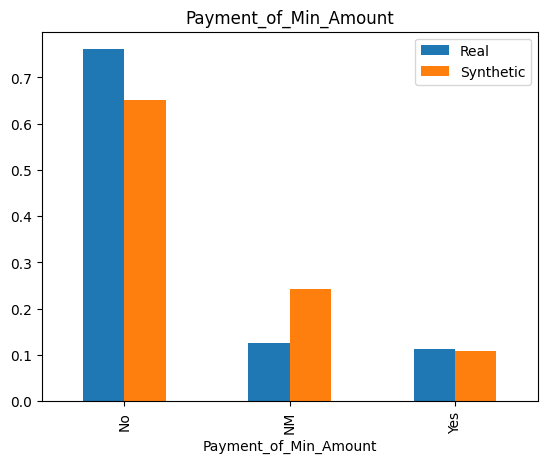


--- Credit_Score ---
              Real  Synthetic
Credit_Score                 
Good           1.0        1.0


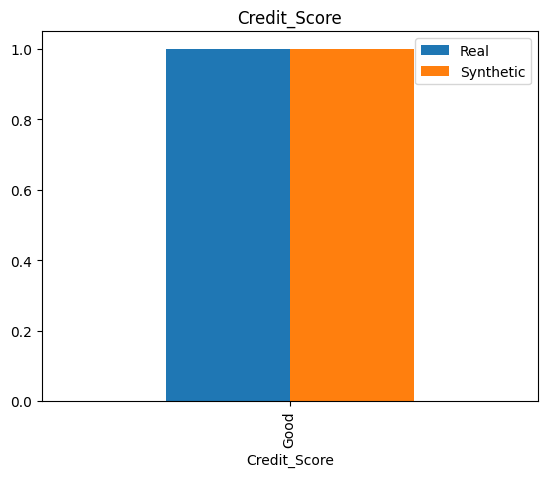


--- Spending_Level ---
                    Real  Synthetic
Spending_Level                     
High            0.490690   0.373604
Low             0.431874   0.489856
Missing         0.077437   0.136540


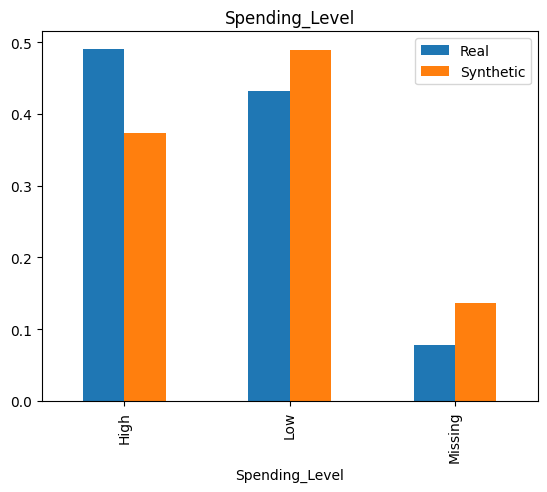


--- Payment_Size ---
                  Real  Synthetic
Payment_Size                     
Large         0.280018   0.395973
Medium        0.335495   0.276263
Missing       0.077437   0.071330
Small         0.307050   0.256434


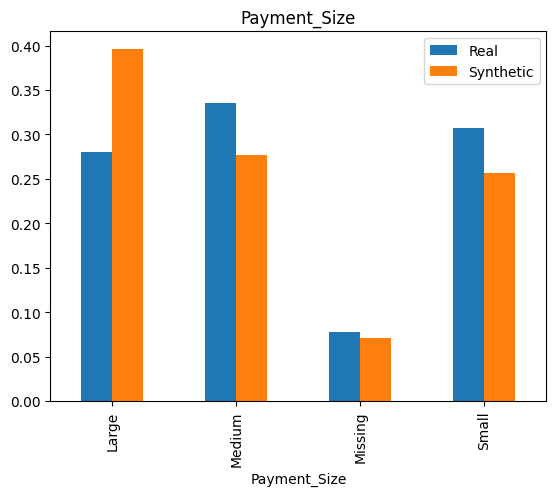

In [14]:
compare_datasets(real=df_good, synthetic=synthetic_good, columns=columns)

## a bunch of tables for df Poor


NUMERICAL COLUMN ANALYSIS

--- Age ---
Real Mean: 31.10 | Synthetic Mean: 27.30
Real Std:  9.96 | Synthetic Std:  10.21


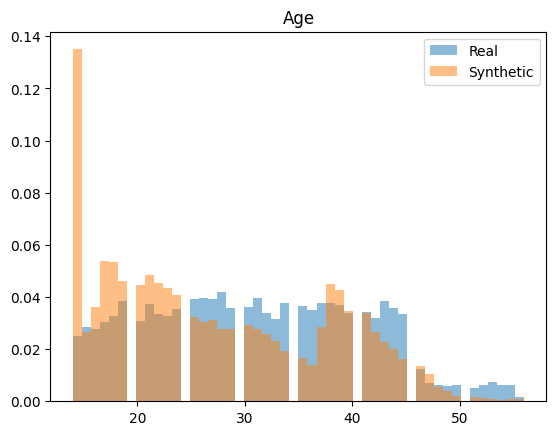


--- Annual_Income ---
Real Mean: 39178.36 | Synthetic Mean: 30580.01
Real Std:  29265.43 | Synthetic Std:  23025.98


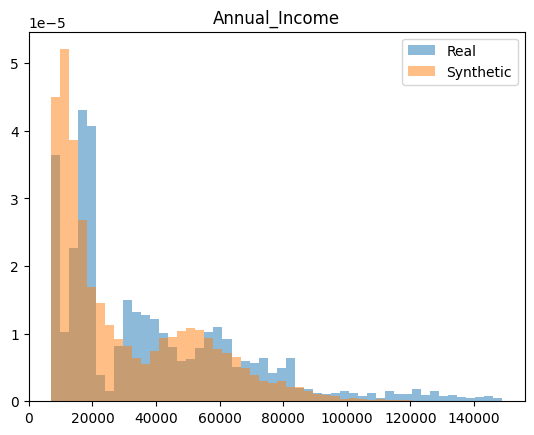


--- Monthly_Inhand_Salary ---
Real Mean: 3263.23 | Synthetic Mean: 3048.80
Real Std:  2440.26 | Synthetic Std:  2379.43


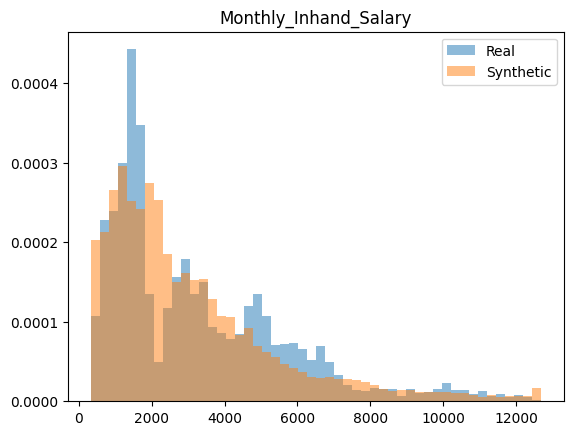


--- Num_Bank_Accounts ---
Real Mean: 6.58 | Synthetic Mean: 6.33
Real Std:  2.48 | Synthetic Std:  2.63


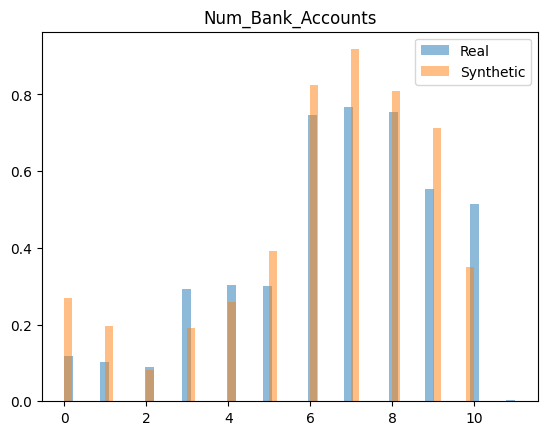


--- Num_Credit_Card ---
Real Mean: 6.64 | Synthetic Mean: 6.67
Real Std:  1.99 | Synthetic Std:  2.20


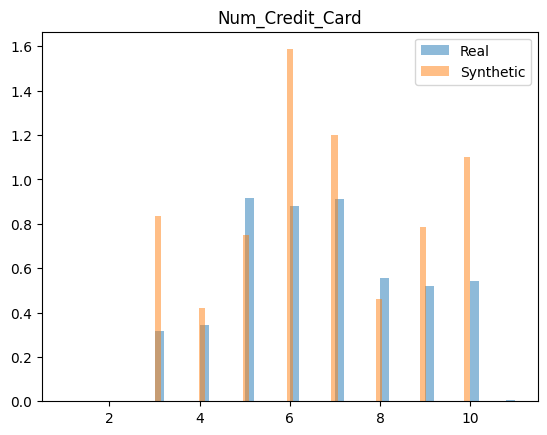


--- Interest_Rate ---
Real Mean: 20.33 | Synthetic Mean: 19.69
Real Std:  8.78 | Synthetic Std:  9.07


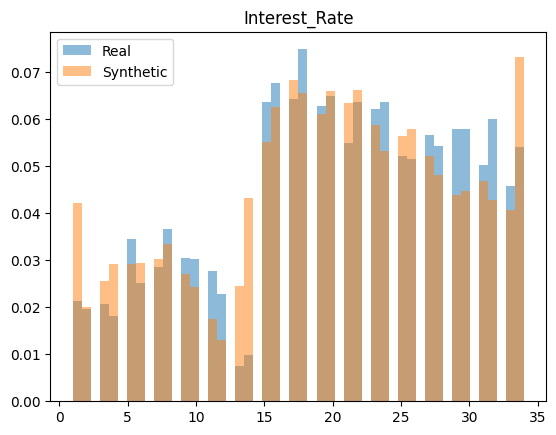


--- Num_of_Loan ---
Real Mean: 4.79 | Synthetic Mean: 4.63
Real Std:  2.43 | Synthetic Std:  2.48


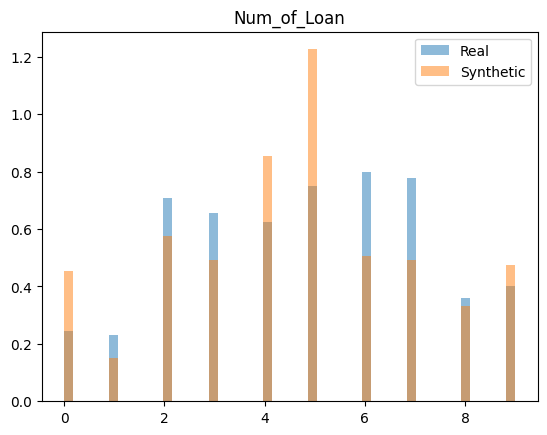


--- Delay_from_due_date ---
Real Mean: 29.92 | Synthetic Mean: 27.51
Real Std:  16.30 | Synthetic Std:  18.45


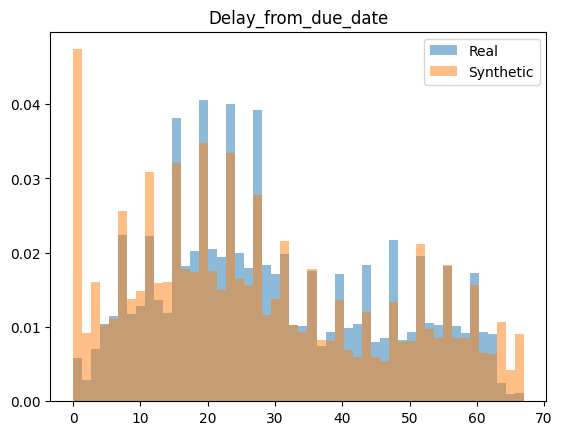


--- Num_of_Delayed_Payment ---
Real Mean: 30.40 | Synthetic Mean: 74.14
Real Std:  206.59 | Synthetic Std:  445.71


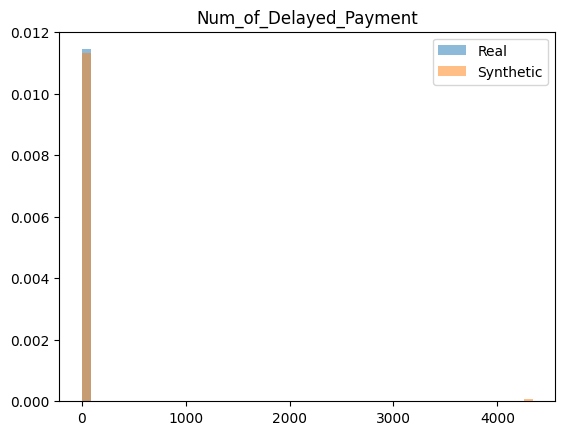


--- Changed_Credit_Limit ---
Real Mean: 11.09 | Synthetic Mean: 10.72
Real Std:  6.89 | Synthetic Std:  7.34


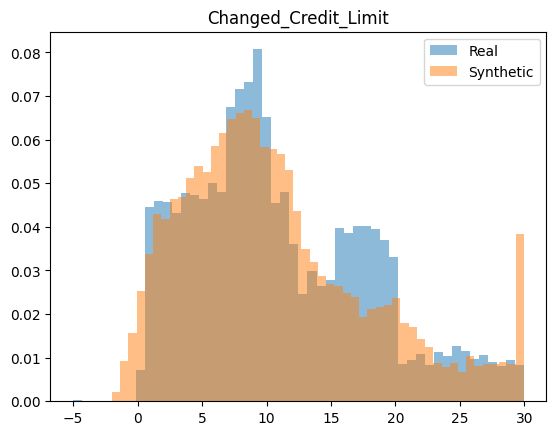


--- Num_Credit_Inquiries ---
Real Mean: 8.14 | Synthetic Mean: 8.28
Real Std:  3.69 | Synthetic Std:  3.64


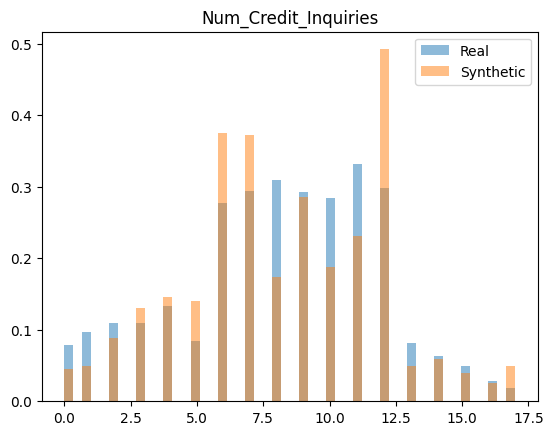


--- Outstanding_Debt ---
Real Mean: 2099.50 | Synthetic Mean: 1863.55
Real Std:  1143.13 | Synthetic Std:  1125.41


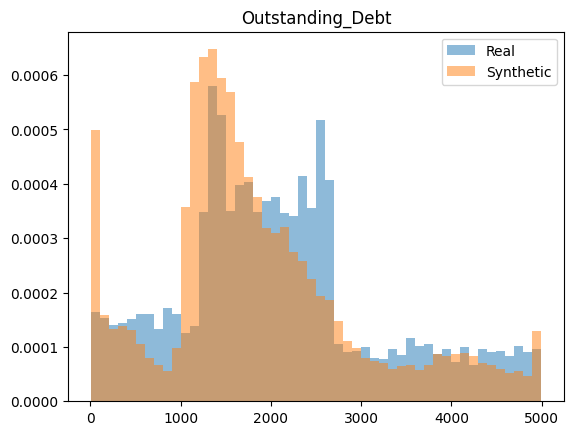


--- Credit_Utilization_Ratio ---
Real Mean: 31.95 | Synthetic Mean: 32.55
Real Std:  5.03 | Synthetic Std:  5.22


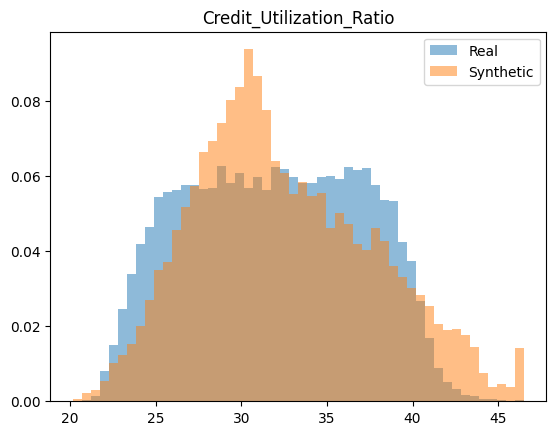


--- Amount_invested_monthly ---
Real Mean: 141.36 | Synthetic Mean: 154.39
Real Std:  97.10 | Synthetic Std:  105.20


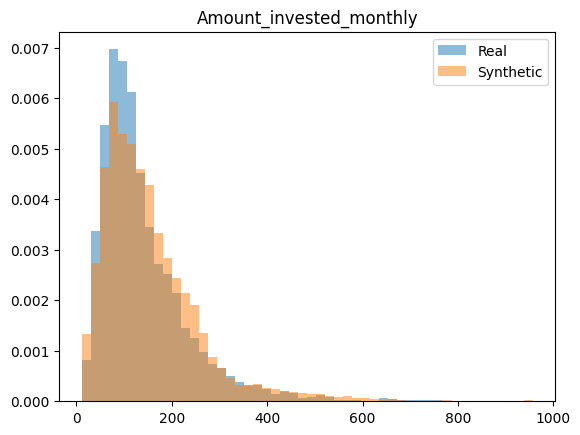


--- Monthly_Balance ---
Real Mean: 338.56 | Synthetic Mean: 318.72
Real Std:  159.96 | Synthetic Std:  142.40


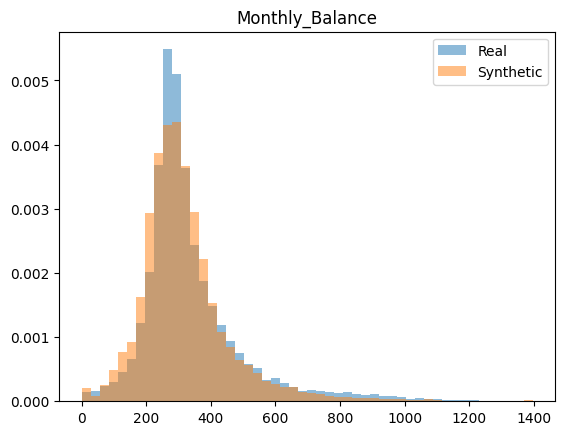


--- Credit_History_Years ---
Real Mean: 13.58 | Synthetic Mean: 12.90
Real Std:  7.24 | Synthetic Std:  6.61


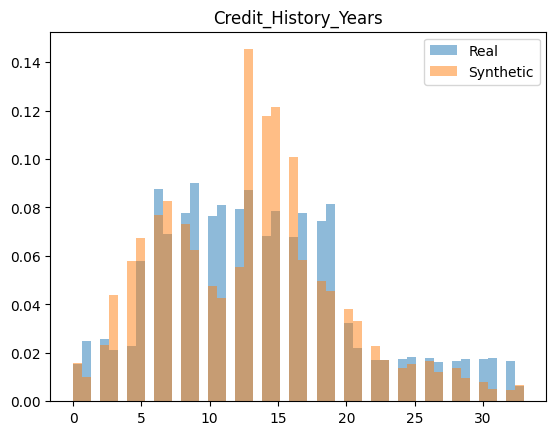


CATEGORICAL COLUMN ANALYSIS

--- Occupation ---
                   Real  Synthetic
Occupation                        
Accountant     0.069822   0.098510
Architect      0.064740   0.059627
Developer      0.067243   0.060998
Doctor         0.061554   0.065293
Engineer       0.071491   0.095952
Entrepreneur   0.070163   0.088550
Journalist     0.063830   0.045874
Lawyer         0.067509   0.065201
Manager        0.062464   0.044412
Mechanic       0.070808   0.069999
Media_Manager  0.061175   0.110527
Musician       0.062123   0.040894
Scientist      0.072174   0.064105
Teacher        0.069139   0.048204
Writer         0.065764   0.041853


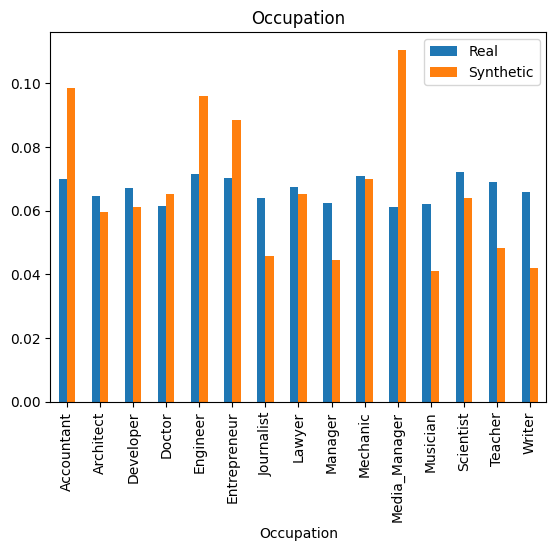


--- Credit_Mix ---
                Real  Synthetic
Credit_Mix                     
Bad         0.497781   0.572969
Standard    0.345470   0.215389
Good        0.156749   0.211642


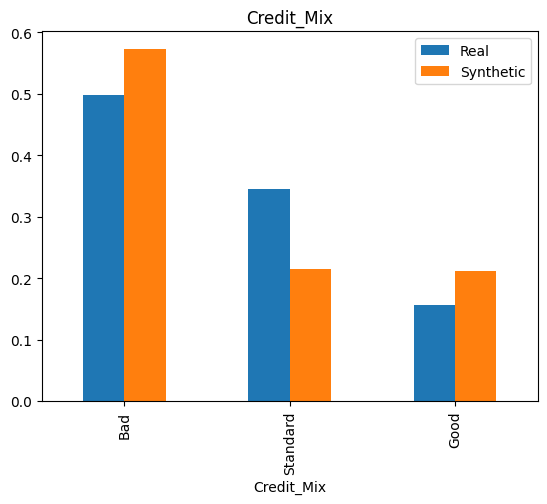


--- Payment_of_Min_Amount ---
                           Real  Synthetic
Payment_of_Min_Amount                     
Yes                    0.722949   0.677648
No                     0.156142   0.177145
NM                     0.120909   0.145207


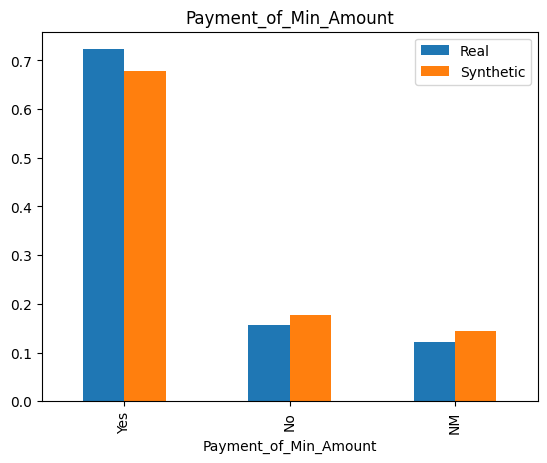


--- Credit_Score ---
              Real  Synthetic
Credit_Score                 
Poor           1.0        1.0


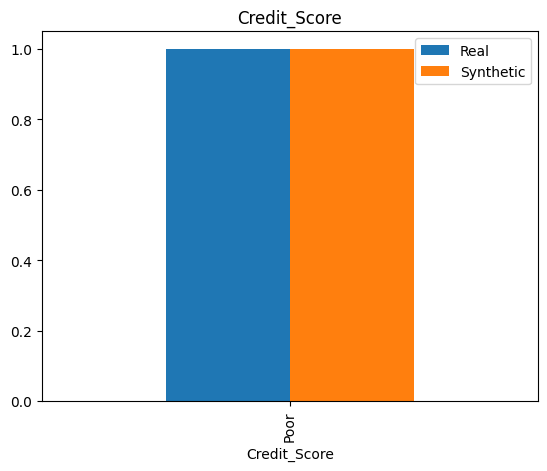


--- Spending_Level ---
                    Real  Synthetic
Spending_Level                     
Low             0.563166   0.485013
High            0.360451   0.431326
Missing         0.076383   0.083661


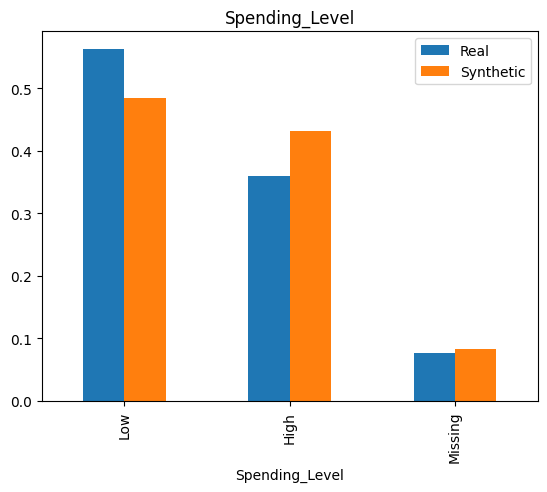


--- Payment_Size ---
                  Real  Synthetic
Payment_Size                     
Small         0.423484   0.515672
Medium        0.298024   0.191127
Large         0.202109   0.180709
Missing       0.076383   0.112492


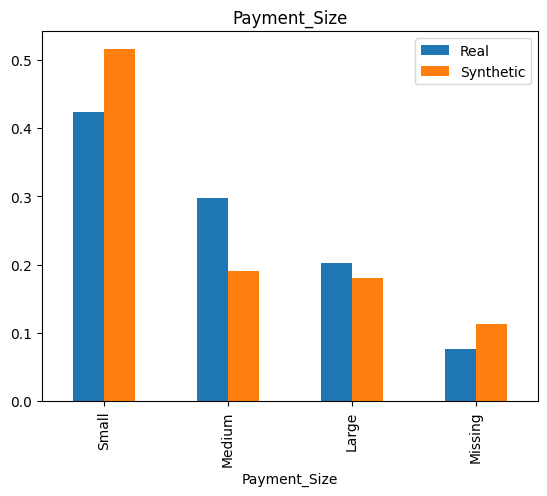

In [15]:
compare_datasets(real=df_poor, synthetic=synthetic_poor, columns=columns)

## a bunch of tables for df standard


NUMERICAL COLUMN ANALYSIS

--- Age ---
Real Mean: 33.36 | Synthetic Mean: 34.15
Real Std:  10.78 | Synthetic Std:  11.68


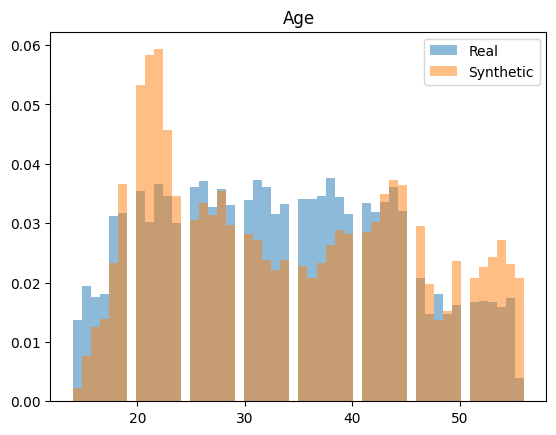


--- Annual_Income ---
Real Mean: 49242.00 | Synthetic Mean: 49428.71
Real Std:  35062.30 | Synthetic Std:  35821.75


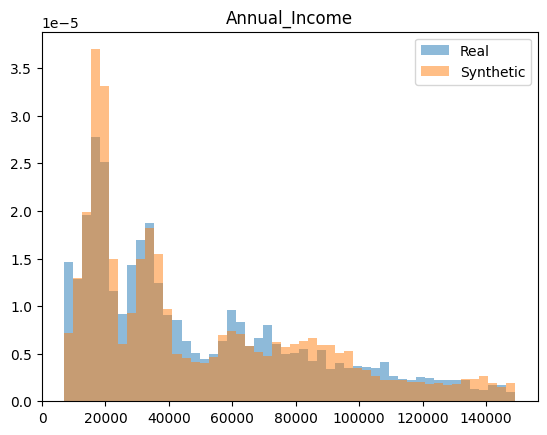


--- Monthly_Inhand_Salary ---
Real Mean: 4093.46 | Synthetic Mean: 3730.01
Real Std:  2919.13 | Synthetic Std:  2512.46


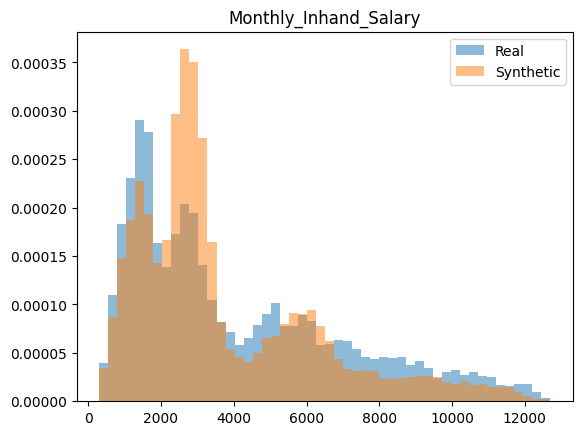


--- Num_Bank_Accounts ---
Real Mean: 5.42 | Synthetic Mean: 5.61
Real Std:  2.35 | Synthetic Std:  2.34


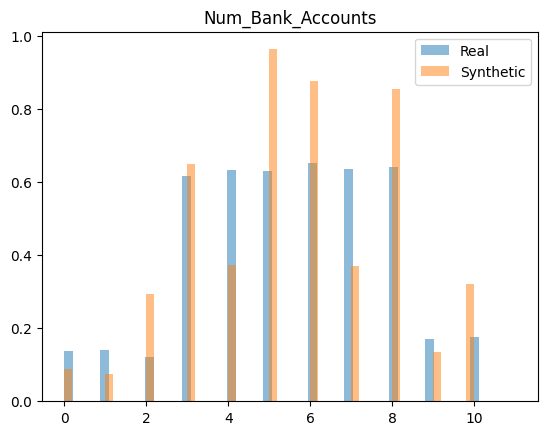


--- Num_Credit_Card ---
Real Mean: 5.42 | Synthetic Mean: 5.52
Real Std:  1.86 | Synthetic Std:  1.80


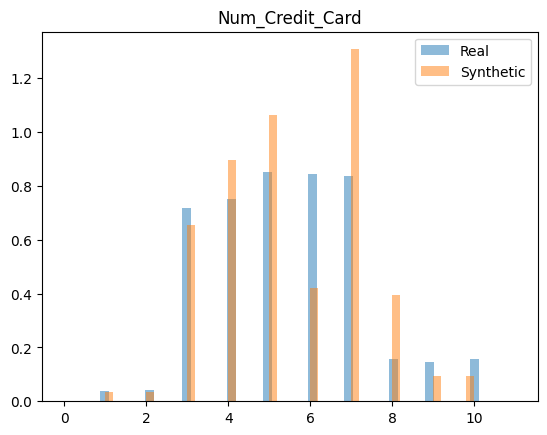


--- Interest_Rate ---
Real Mean: 13.85 | Synthetic Mean: 14.60
Real Std:  7.67 | Synthetic Std:  7.78


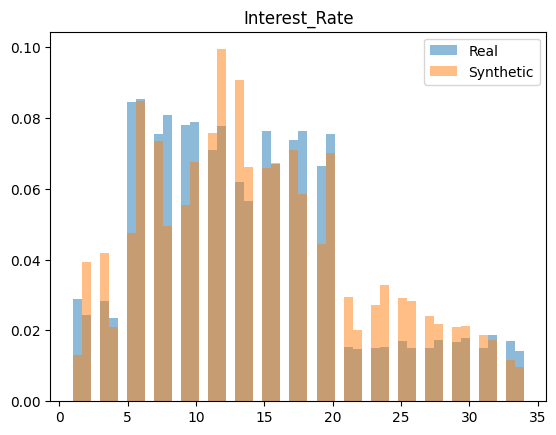


--- Num_of_Loan ---
Real Mean: 3.34 | Synthetic Mean: 3.50
Real Std:  2.38 | Synthetic Std:  2.59


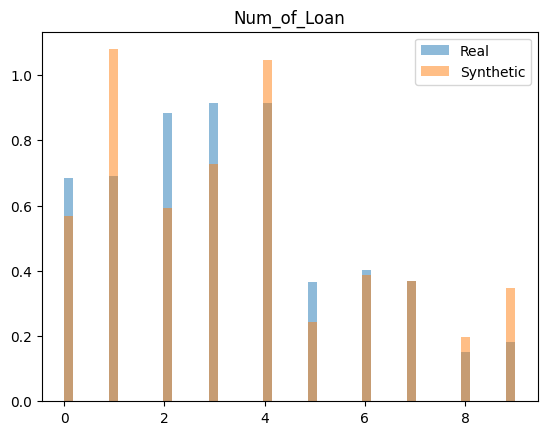


--- Delay_from_due_date ---
Real Mean: 19.93 | Synthetic Mean: 19.76
Real Std:  12.96 | Synthetic Std:  13.29


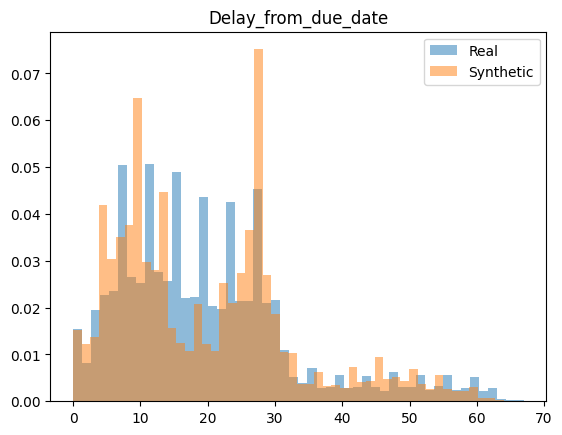


--- Num_of_Delayed_Payment ---
Real Mean: 30.49 | Synthetic Mean: 83.56
Real Std:  220.29 | Synthetic Std:  451.49


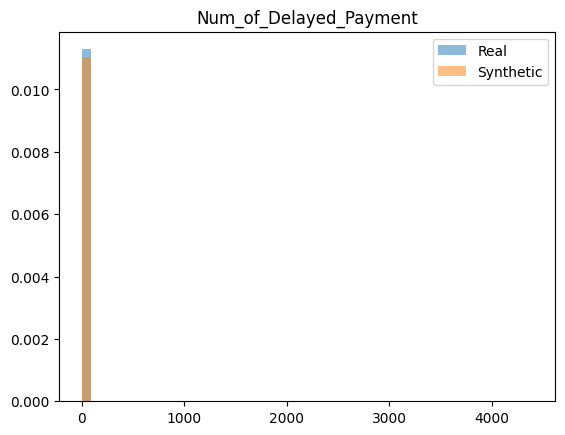


--- Changed_Credit_Limit ---
Real Mean: 11.20 | Synthetic Mean: 12.94
Real Std:  6.51 | Synthetic Std:  6.25


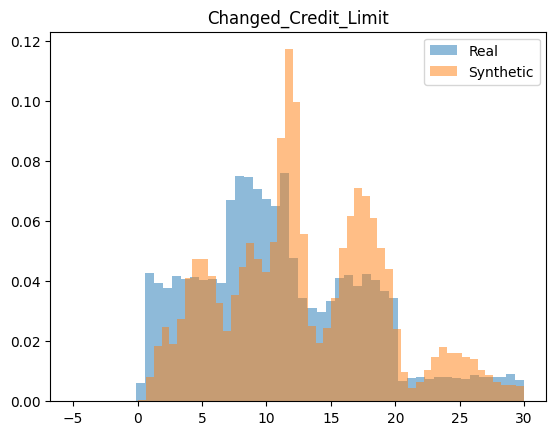


--- Num_Credit_Inquiries ---
Real Mean: 5.29 | Synthetic Mean: 5.10
Real Std:  3.55 | Synthetic Std:  3.23


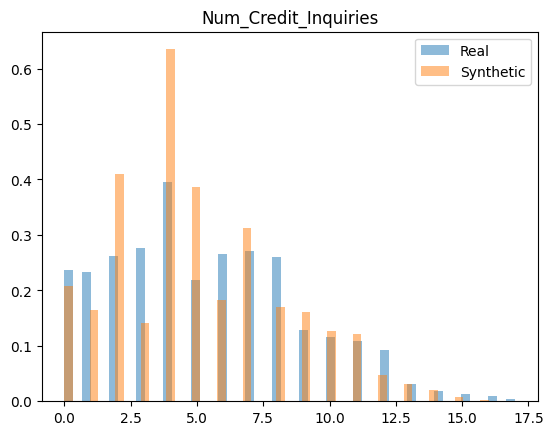


--- Outstanding_Debt ---
Real Mean: 1285.19 | Synthetic Mean: 1302.90
Real Std:  1137.35 | Synthetic Std:  1103.13


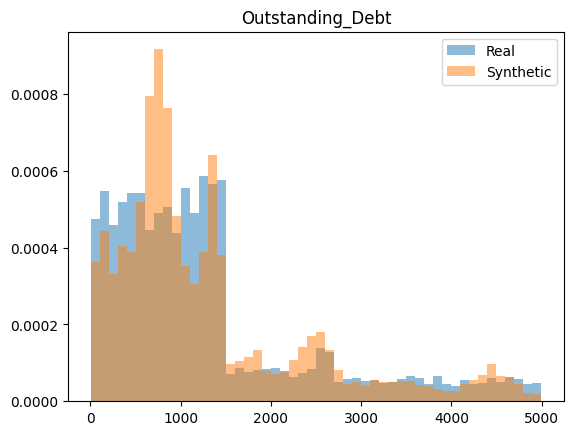


--- Credit_Utilization_Ratio ---
Real Mean: 32.26 | Synthetic Mean: 30.79
Real Std:  5.08 | Synthetic Std:  5.30


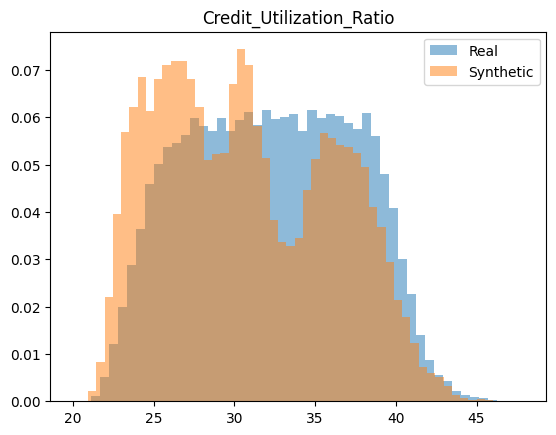


--- Amount_invested_monthly ---
Real Mean: 166.89 | Synthetic Mean: 153.57
Real Std:  114.97 | Synthetic Std:  115.02


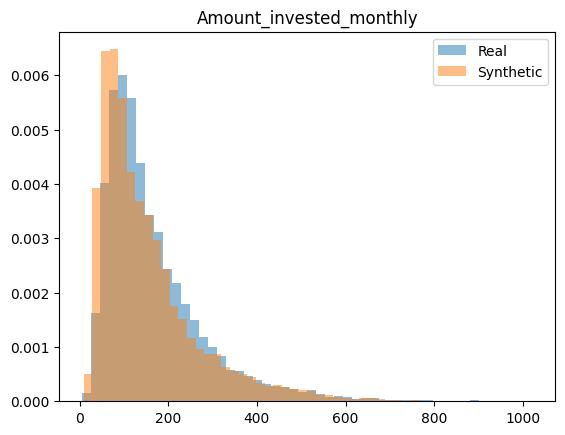


--- Monthly_Balance ---
Real Mean: 401.61 | Synthetic Mean: 406.24
Real Std:  199.12 | Synthetic Std:  183.39


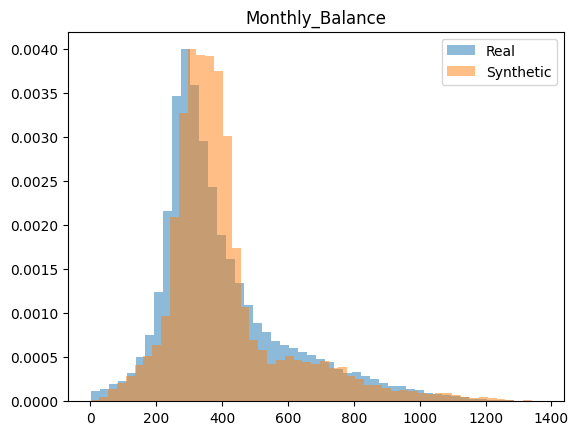


--- Credit_History_Years ---
Real Mean: 18.45 | Synthetic Mean: 19.64
Real Std:  8.30 | Synthetic Std:  8.46


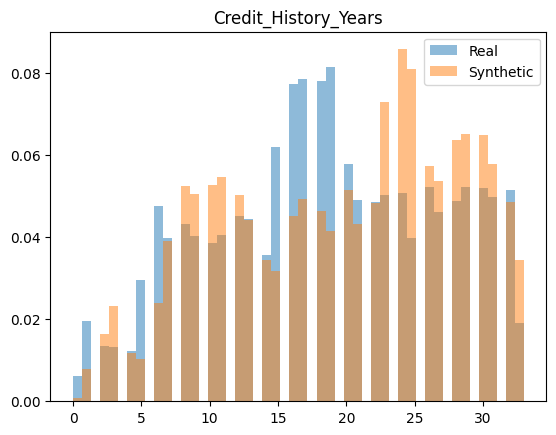


CATEGORICAL COLUMN ANALYSIS

--- Occupation ---
                   Real  Synthetic
Occupation                        
Accountant     0.065530    0.05655
Architect      0.070193    0.09425
Developer      0.067706    0.05125
Doctor         0.067913    0.05430
Engineer       0.065882    0.07700
Entrepreneur   0.064348    0.05215
Journalist     0.064576    0.04690
Lawyer         0.072493    0.06850
Manager        0.063312    0.06115
Mechanic       0.068265    0.04245
Media_Manager  0.069198    0.07785
Musician       0.063934    0.06980
Scientist      0.065903    0.03930
Teacher        0.064245    0.13895
Writer         0.066504    0.06960


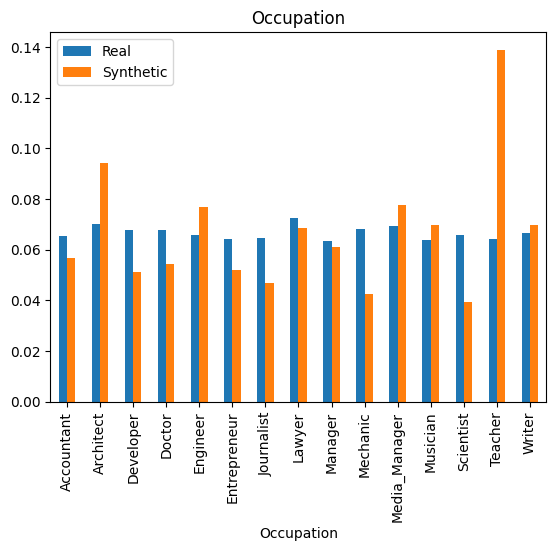


--- Credit_Mix ---
                Real  Synthetic
Credit_Mix                     
Standard    0.637784     0.5045
Good        0.188672     0.2641
Bad         0.173544     0.2314


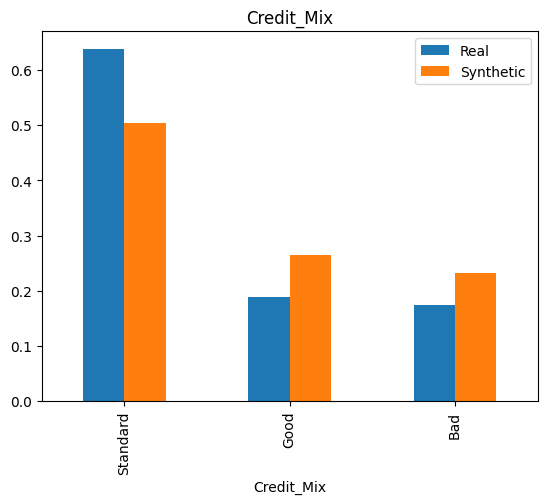


--- Payment_of_Min_Amount ---
                           Real  Synthetic
Payment_of_Min_Amount                     
Yes                    0.566742    0.62335
No                     0.315835    0.30775
NM                     0.117423    0.06890


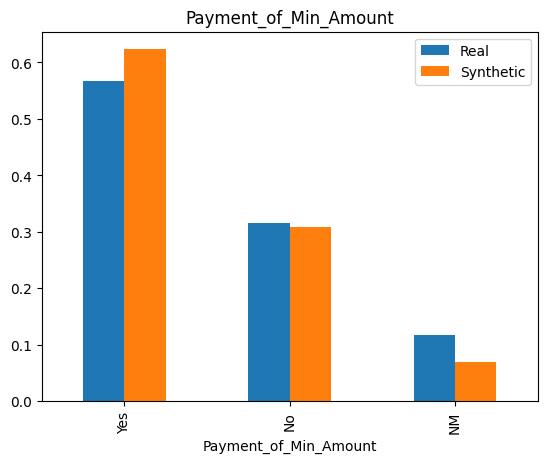


--- Credit_Score ---
              Real  Synthetic
Credit_Score                 
Standard       1.0        1.0


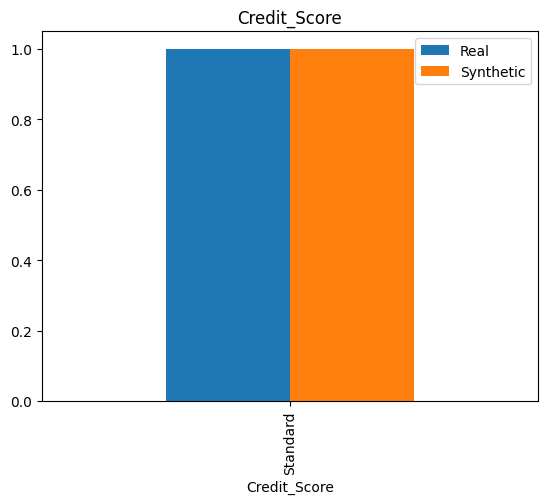


--- Spending_Level ---
                    Real  Synthetic
Spending_Level                     
Low             0.489255     0.4271
High            0.435786     0.4058
Missing         0.074959     0.1671


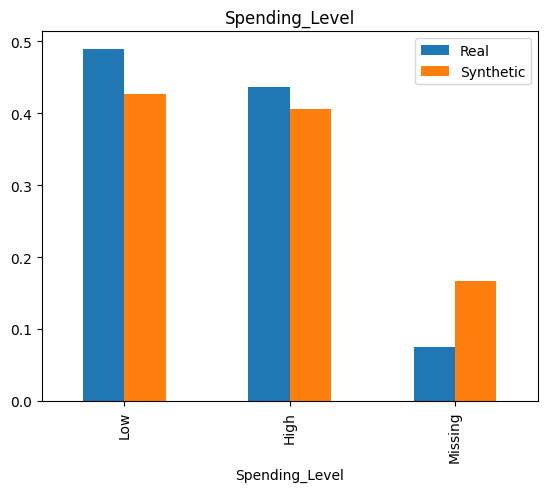


--- Payment_Size ---
                  Real  Synthetic
Payment_Size                     
Large         0.246347     0.2588
Medium        0.313804     0.2422
Missing       0.074959     0.1242
Small         0.364889     0.3748


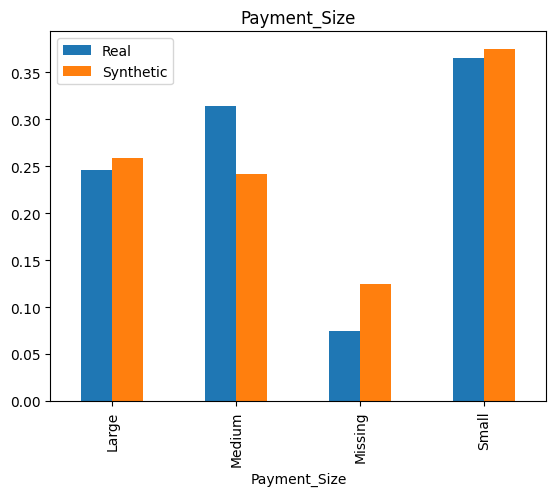

In [16]:
compare_datasets(real=df_standard, synthetic=synthetic_standard_sampled, columns=columns)